# Numpy

Структура занятия:

1) Введение, массивы

2) Доступ к элементам и срезам

3) Выполнение вычислений

4) Индексация

5) Сортировка

6) Структуры

## Введение

Библиотека NumPy предоставляет реализации вычислительных алгоритмов (в виде функций и операторов), оптимизированные для работы с многомерными массивами, структуры NumPy эффективно хранят данные.

Вспомним как хранятся данные в Python...

Целое число в Python - это больше чем просто целое число. Целочисленный тип хранится в виде структуры [языка Си](https://github.com/python/cpython/blob/main/Objects/longobject.c#L140), содержит счётчик ссылок, кодирующий тип, фактическое целочисленное значение и т.д. Это значит, что существует достаточно большая избыточность хранения данных, в сравнении с компилируемыми языками, такими как Си. 

Анаогично, список в Python - это больше чем просто список. Список содержит указатель на блок указателей, каждый из которых, в свою очередь, указывает на целый объект языка Python, например, целое число. 

Преимущество массива Python - гибкость. Недостаток - низкая эффективность хранения данных и их обработки. 

Встроенный модуль `array` можно использовать для плотного (эффективного) хранения данных одного типа.

In [25]:
import array

data = array.array('i', range(100))
data

array('i', [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [26]:
from sys import getsizeof

getsizeof(data), getsizeof(list(range(100)))

(488, 856)

Массивы NumPy, помимо эффективного хранения данных, обеспечивают также возможность выполнения эффективных операций над этими данными.

In [27]:
pip install numpy


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
import numpy as np

np.array(range(100))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

Важно отметить, что массивы NumPy могут содержать элементы только одного типа. Если типы элементов не совпадают, NumPy пытается привести элементы к одному типу

In [29]:
np.array(list(range(10)) + [0.1])

array([0. , 1. , 2. , 3. , 4. , 5. , 6. , 7. , 8. , 9. , 0.1])

In [30]:
np.array(list(range(10)) + ['1'])

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '1'],
      dtype='<U21')

In [31]:
np.array(list(range(10)) + [0.1, '1'])

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '0.1', '1'],
      dtype='<U32')

Есть возможность явно задать тип массива

In [32]:
np.array(range(10), dtype='float64')

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

Все типы

Как ещё можно создать массив:

In [33]:
# массив нулей
np.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [34]:
# массив как range
np.arange(20, 40, 2)

array([20, 22, 24, 26, 28, 30, 32, 34, 36, 38])

In [35]:
# 3х мерный массив из списков
np.array([[1,2,3], [4,5,6], [7,8,9]])

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [36]:
# массив единиц
np.ones((3, 2))

array([[1., 1.],
       [1., 1.],
       [1., 1.]])

In [37]:
# диагональная матрица
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [38]:
# матрица c равномерно распределёнными случайными значениями
np.random.random((3, 2))

array([[0.19538361, 0.2362129 ],
       [0.84573844, 0.60974425],
       [0.56132377, 0.94654959]])

In [39]:
# матрица c нормально распределёнными случайными значениями с медианой 0 и ст. отклонением 2
np.random.normal(0, 2, (3, 2))

array([[-0.15730611,  2.43291025],
       [ 3.18973148, -0.04562335],
       [-1.30039734, -1.88101902]])

## Доступ к элементам

Доступ по индексам

In [40]:
A = np.array([[1,2,3], [4,5,6], [7,8,9]])
A[1, 2]  # особенный синтаксис np

np.int64(6)

In [41]:
A[1][2]

np.int64(6)

In [42]:
A[1, -1]

np.int64(6)

In [43]:
B = A.copy()  # обратите внимание, создаётся полная копия!
B[1][2] = 66
B

array([[ 1,  2,  3],
       [ 4,  5, 66],
       [ 7,  8,  9]])

In [44]:
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [45]:
a = [[1,2,3], [4,5,6], [7,8,9]]  # обычный массив (список) питона
b = a.copy()  # при работе со списком, создаётся поверхностная копия
b[1][2] = 66
b

[[1, 2, 3], [4, 5, 66], [7, 8, 9]]

In [46]:
a

[[1, 2, 3], [4, 5, 66], [7, 8, 9]]

In [47]:
A[::-1]

array([[7, 8, 9],
       [4, 5, 6],
       [1, 2, 3]])

Дополнительные возможности работы со срезами

In [48]:
A[:2, :2]  # 2 строки и 2 столбца

array([[1, 2],
       [4, 5]])

In [49]:
A[:2, ::2]  # 2 строки и каждый 2-й столбец

array([[1, 3],
       [4, 6]])

In [50]:
A[::-1, ::-1]  # пееворачивание подмассивов

array([[9, 8, 7],
       [6, 5, 4],
       [3, 2, 1]])

In [51]:
A[:, 0] # первый столбец

array([1, 4, 7])

In [52]:
A[1, :] # вторая строка

array([4, 5, 6])

Срезы возвращают не копии массивов, а их предсавления. Это значит что изменение помассива (среза) повлечёт за собой изменение исходного массива. Для создания копий, необходимо использовать метод `.copy()`

In [53]:
a_sub = A[:2, :2]
a_sub

array([[1, 2],
       [4, 5]])

In [54]:
a_sub[0, 0] = 100
A

array([[100,   2,   3],
       [  4,   5,   6],
       [  7,   8,   9]])

Можно изменять форму массива при помощи метода `.reshape()`. При этом, размер исходного массива и преобразования должны соответствовать друг другу.

In [55]:
# поместим числа от 1 до 10 в таблицу 3x3
np.arange(1, 10).reshape((3, 3))

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [56]:
np.arange(12).reshape((2, 6))

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

При помощи методов `.concatenate()`, `.split()` массивы можно объединять и разбивать

In [57]:
np.concatenate([A, A])

array([[100,   2,   3],
       [  4,   5,   6],
       [  7,   8,   9],
       [100,   2,   3],
       [  4,   5,   6],
       [  7,   8,   9]])

In [58]:
np.concatenate([A, A], axis=1)

array([[100,   2,   3, 100,   2,   3],
       [  4,   5,   6,   4,   5,   6],
       [  7,   8,   9,   7,   8,   9]])

In [59]:
np.split(A, [1, 1])  # кроме массива задаём точки раздела

[array([[100,   2,   3]]),
 array([], shape=(0, 3), dtype=int64),
 array([[4, 5, 6],
        [7, 8, 9]])]

In [60]:
np.split(A, [1, 1], axis=1)  # кроме массива задаём точки раздела

[array([[100],
        [  4],
        [  7]]),
 array([], shape=(3, 0), dtype=int64),
 array([[2, 3],
        [5, 6],
        [8, 9]])]

## Выполнение вычислений

Ключ к ускорению обработки массивов - использование векторизованных операций.

Многие (но не все) функции NumPy работают с разблокированным GIL!

Сравим скорость обработки массива стандартным способом, то есть при помощи цикла и использование веркоризованных (направленных на вектор) операций.

In [61]:
def compute_negative(arr):
    result = np.empty(len(arr))
    for i in range(len(arr)):
        result[i] = -arr[i]
    return result

V = np.random.random(size=100_000)
%timeit compute_negative(V)  # через цикл

6.91 ms ± 242 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [62]:
%timeit (-V)  # через векторизованные операции

13.3 μs ± 541 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Векторизованные операции реализованы посредством *универсальных функций*, которые позволяют быстро выполнять повторяющиеся операции на массивах NumPy 

Универсальные функции делятся на унарные и бинарные, список:
- унарные: `-`, `np.abs()`, `np.sin()`, `np.log()`, `np.exp()`, и т.д.
- бинарные: `+`, `-`, `*`, `**`, `/`, `//`, `%`, и т.д.

Арифметические операторы являются адаптерами для функций, например `+` = `np.add()`

Все универсальные функции имеют дополнительный метод `.reduce()`

In [63]:
A = np.random.random(size=100_000)
np.add.reduce(A)

np.float64(50013.7132714123)

Агрегирования:

In [64]:
# сумма
np.sum(A)
np.add.reduce(A)

np.float64(50013.7132714123)

In [65]:
# минимум и максимум
np.min(A), np.max(A)
np.minimum.reduce(A)

np.float64(1.1514162723602617e-05)

In [66]:
M = np.random.random((3, 3))
M

array([[0.48619936, 0.09846541, 0.29405673],
       [0.06991223, 0.78321065, 0.43611628],
       [0.41117203, 0.00177654, 0.74139123]])

In [67]:
np.sum(M)

np.float64(3.3223004727767256)

In [68]:
np.sum(M, axis=0)

array([0.96728362, 0.8834526 , 1.47156425])

In [69]:
np.sum(M, axis=1)

array([0.87872151, 1.28923916, 1.1543398 ])

Возможные агрегирования:
- `np.sum` - сумма
- `np.mean` - среднее
- `np.std` - стандартное отклонение
- `np.var` - дисперсия
- `np.median` - медиана
- `np.percentile` - квантили элементов
- `np.all` - все ли элементы истины
- `np.any` - есть ли среди элементов истинный

Транслирования - правила применения бинарных универсальных функций к массивам различной длины.

In [70]:
M + 5  # простой случай - сложение применяется ко всем элементам

array([[5.48619936, 5.09846541, 5.29405673],
       [5.06991223, 5.78321065, 5.43611628],
       [5.41117203, 5.00177654, 5.74139123]])

In [71]:
M + M  # простой случай - сложение происходит попарно между элементами с одинаковыми индексами

array([[0.97239873, 0.19693082, 0.58811347],
       [0.13982446, 1.56642129, 0.87223257],
       [0.82234406, 0.00355308, 1.48278246]])

In [72]:
M + np.array([1, 2, 3])  # сложение происходит по столбцам

array([[1.48619936, 2.09846541, 3.29405673],
       [1.06991223, 2.78321065, 3.43611628],
       [1.41117203, 2.00177654, 3.74139123]])

In [73]:
M + np.array([1, 2, 3]).reshape((3, 1))  # сложение по строкам

array([[1.48619936, 1.09846541, 1.29405673],
       [2.06991223, 2.78321065, 2.43611628],
       [3.41117203, 3.00177654, 3.74139123]])

Маски. Универсальные функции `>`, `<`, `=`, `!=` позволяют создать маски, то есть классифицировать данные по какому либо признаку, преобразовать массивы к виду истина / ложь. Это необходимо, если мы хотим ответить на какой-либо конкретный вопрос

In [74]:
M

array([[0.48619936, 0.09846541, 0.29405673],
       [0.06991223, 0.78321065, 0.43611628],
       [0.41117203, 0.00177654, 0.74139123]])

In [75]:
M.mean(axis=0)

array([0.32242787, 0.2944842 , 0.49052142])

In [76]:
M > M.mean()

array([[ True, False, False],
       [False,  True,  True],
       [ True, False,  True]])

In [77]:
M.sum(axis=1)

array([0.87872151, 1.28923916, 1.1543398 ])

In [78]:
np.sum(M < M.mean())  # сочетание агрегации и маски

np.int64(4)

Условия можно сочетать при помощи логических операторов `&` (and), `|` (or), `^` (xor), `~` (not)

In [79]:
(M > M.mean()) | (M == M.min())

array([[ True, False, False],
       [False,  True,  True],
       [ True,  True,  True]])

### Пример. Статистики по росту людей

In [80]:
import csv

heights = []

with open("/home/ifan/projects/bmstu/krasnovatiy/lessons_2026/15_np/weight_height.csv") as csvfile:
    r = csv.DictReader(csvfile)
    for i in r:
        heights.append(float(i['Height']))

In [81]:
heights_arr = np.array(heights)

In [125]:
heights_arr

array([187.57142322, 174.70603628, 188.2396677 , ..., 162.22470022,
       175.34697755, 157.33838453], shape=(10000,))

In [83]:
heights_arr.mean(), heights_arr.max(), heights_arr.min()

(np.float64(168.57360177724595),
 np.float64(200.6568055598296),
 np.float64(137.82835864574665))

In [84]:
heights_arr.std(), np.median(heights_arr), np.percentile(heights_arr, 75), np.percentile(heights_arr, 25)

(np.float64(9.772232778476152),
 np.float64(168.447898007733),
 np.float64(175.70262478616016),
 np.float64(161.30427602229614))

Так как куда интереснее видеть графическое представление данных, воспользуемся библиотекой `matplotlib`. Она отлично интегрированна в Jupyter

In [85]:
pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


(array([  23.,  218.,  926., 1906., 2196., 2167., 1612.,  765.,  163.,
          24.]),
 array([137.82835865, 144.11120334, 150.39404803, 156.67689272,
        162.95973741, 169.2425821 , 175.52542679, 181.80827149,
        188.09111618, 194.37396087, 200.65680556]),
 <BarContainer object of 10 artists>)

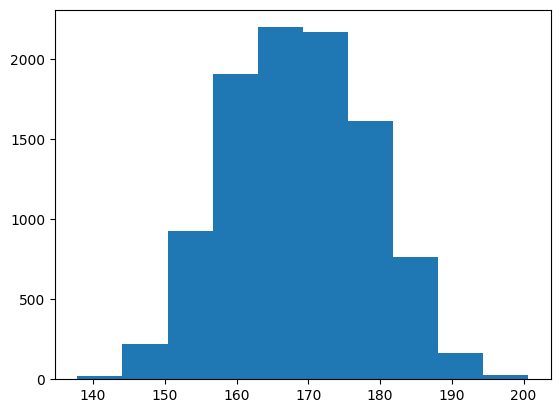

In [86]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.hist(heights_arr)

Точные численные данные

In [126]:
np.count_nonzero(heights_arr)

np.int64(10000)

In [127]:
h_h = np.percentile(heights_arr, 98)
np.count_nonzero(heights_arr >= h_h), np.count_nonzero(heights_arr < h_h), h_h

(np.int64(200), np.int64(9800), np.float64(187.92422965671105))

In [128]:
l_h = np.percentile(heights_arr, 2)
np.count_nonzero(heights_arr >= l_h), np.count_nonzero(heights_arr < l_h), l_h

(np.int64(9800), np.int64(200), np.float64(149.75824261557102))

## Индексация

In [129]:
A = np.random.randint(0, 20, size=12)
A

array([14, 15, 14,  3, 12, 11,  9,  8,  7,  7, 16, 18])

Нужные элементы можно запрашивать напрямую, с указанием индексов 

In [130]:
[A[1], A[5], A[3]]

[np.int64(15), np.int64(11), np.int64(3)]

Но лучшим способом является передача массива индексов

In [131]:
idx = [1, 5, 3]
A[idx]

array([15, 11,  3])

Такая индексация работает с многомерными массивами, при этом необходимо передавать индексы нужных измерений для каждого элемента

In [133]:
A = np.random.randint(0, 20, size=12).reshape((4, 3))
A

array([[ 2, 19,  0],
       [ 6,  4,  0],
       [ 3, 15, 13],
       [10,  2, 11]])

In [134]:
row = [0, 1, 3]
col = [0, 2, 2]
A[row, col]

array([ 2,  0, 11])

Можно совмещать простые индексы и массивы индексов

In [95]:
row = 1
col = [0, 2, 2]
A[row, col]

array([16,  2,  2])

Частая сфера применения разного рода индексаций - выборка подмножеств данных, например, для разделения датасетов на обучающую и тестовую выборки.

In [135]:
import csv

weights = []

with open("weight_height.csv") as csvfile:
    r = csv.DictReader(csvfile)
    for i in r:
        weights.append(float(i['Weight']))
        
weights_arr = np.array(weights)

In [136]:
np.count_nonzero(heights_arr), np.count_nonzero(weights_arr)

(np.int64(10000), np.int64(10000))

In [98]:
heights_arr.shape, weights_arr.shape

((10000,), (10000,))

In [99]:
X = np.stack([heights_arr, weights_arr], axis=-1)  # объединили рост и вес по индексу записи

In [100]:
X.shape

(10000, 2)

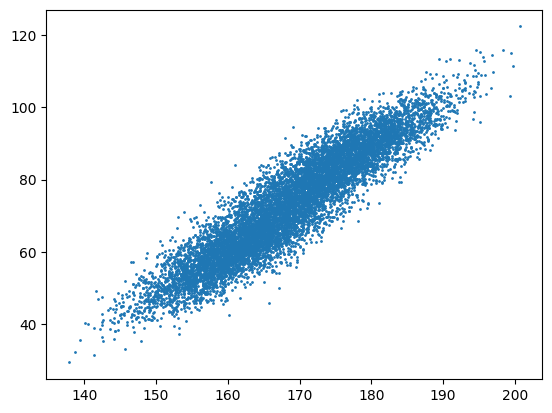

In [101]:
plt.scatter(X[:, 0], X[:, 1], s=1)

1000 случайных элементов отберём для теста, используя индексацию

In [102]:
indexes = np.random.choice(X.shape[0], 1000, replace=False)

In [103]:
indexes

array([7037, 2236, 9063, 8120, 1095, 8534, 5737, 5289, 3004, 3686, 4700,
       3137, 9191, 7069,  555, 3190, 5537, 1198, 4323, 3635, 2652, 8090,
       8698, 8310, 2595, 4645, 6804, 4124, 7095, 3922, 1192, 5386, 8000,
       1363, 4570, 5571, 1646, 2323, 1846, 4364, 3225,  708,  948, 1582,
        846, 7420, 4830, 4137, 2606, 2886, 9246,  656, 7362,  784, 4808,
       2680,  619, 7852, 3675,  927, 1183, 9551, 7497, 9951, 2400, 3193,
       4923, 9082, 2630, 8977,  404, 9646, 8890, 6853, 5143, 6534, 1291,
       6224, 3646, 2440, 7163, 1524, 7016, 9851, 3904, 1405, 2582, 3260,
       8421, 5845, 6407, 3410, 4578,  186, 9182, 1858, 5047, 7109, 7360,
       4571, 7386, 7994, 4455, 4827, 7956, 5728, 8572, 7915, 7621,  597,
       8872, 4672, 2560,  920, 3991, 8266, 6765, 5134, 1607, 8394, 2350,
       9674, 6572, 4413, 1330, 5148, 3259, 2248, 3814, 3954, 9739, 3571,
       7928, 1128, 7541, 2583, 4843, 2537, 2497, 7349, 6697, 3161,   76,
        981, 5322, 7997, 6082, 1213, 8770,   55, 97

In [104]:
selected_test = X[indexes]
selected_test.shape

(1000, 2)

Визуализируем тестовую выборку на данных

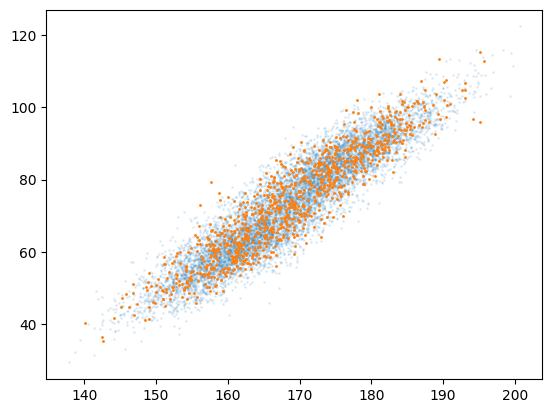

In [105]:
plt.scatter(X[:, 0], X[:, 1], alpha=0.1, s=1)
plt.scatter(selected_test[:, 0], selected_test[:, 1], s=1)


## Сортировка

По умолчанию используется метод timsort, хотя по желанию можно использовать heapsort, quicksort, mergesort.

In [106]:
A = np.random.randint(0, 20, size=12)
A

array([ 4,  3, 11,  0, 11, 10, 17,  5,  4, 12,  9, 10])

In [107]:
B = A.copy()
B.sort()
B

array([ 0,  3,  4,  4,  5,  9, 10, 10, 11, 11, 12, 17])

Также есть функция `argsort`, которая возвращает индексы отсортированных элементов

In [108]:
C = A.copy()
x = C.argsort()
x

array([ 3,  1,  0,  8,  7, 10,  5, 11,  2,  4,  9,  6])

In [109]:
X

array([[187.57142322, 109.70229623],
       [174.70603628,  73.61019162],
       [188.2396677 ,  96.48111363],
       ...,
       [162.22470022,  58.2654507 ],
       [175.34697755,  74.30950628],
       [157.33838453,  51.54154316]], shape=(10000, 2))

С сортировкой 2-х мерных (многомерных) массивов сложнее: все строки и столбцы рассматриваются как отдельные элементы и взаимосвязи между ними теряются

In [110]:
x_sorted = X.copy()
x_sorted.sort()  # сортируем столбцы - данные смешиваются
x_sorted

array([[109.70229623, 187.57142322],
       [ 73.61019162, 174.70603628],
       [ 96.48111363, 188.2396677 ],
       ...,
       [ 58.2654507 , 162.22470022],
       [ 74.30950628, 175.34697755],
       [ 51.54154316, 157.33838453]], shape=(10000, 2))

In [111]:
x_sorted = X.copy()
x_sorted.sort(axis=0)  # сортируем строки - и так данные смешиваются
x_sorted

array([[137.82835865,  29.34246109],
       [138.72681889,  31.28459415],
       [139.37926793,  32.37811734],
       ...,
       [199.46165448, 115.95956228],
       [199.69828988, 116.03778979],
       [200.65680556, 122.44430771]], shape=(10000, 2))

In [137]:
X.T[0] > 198

array([False, False, False, ..., False, False, False], shape=(10000,))

In [138]:
X[X.T[0] > 198]  # рост больше

array([[198.36350338, 115.95956228],
       [199.29361442, 103.10320403],
       [200.65680556, 122.44430771],
       [199.46165448, 115.14240537],
       [199.69828988, 111.44389239]])

In [139]:
X[X.T[0] < 140]  # рост меньше

array([[138.72681889,  32.37811734],
       [139.37926793,  35.64928359],
       [137.82835865,  29.34246109]])

In [115]:
X[X.T[1] > 115]  # вес больше

array([[198.36350338, 115.95956228],
       [194.60856668, 116.03778979],
       [200.65680556, 122.44430771],
       [199.46165448, 115.14240537],
       [195.19585362, 115.28756153]])

In [116]:
X[X.T[1] < 35]  # вес меньше

array([[141.39723339,  31.28459415],
       [138.72681889,  32.37811734],
       [137.82835865,  29.34246109],
       [145.67685561,  32.9932629 ]])

## Структуры данных

Можно задать контейнеры с именованными полями, таким образом, связать данные в структуры

In [140]:
types = {
    'names': ('heights', 'weights'),
    'formats': ('float32', 'float32'),
}
data = np.zeros(10000, dtype=types)
data['heights'] = heights_arr
data['weights'] = weights_arr

In [142]:
data['heights']

array([187.57143, 174.70604, 188.23967, ..., 162.2247 , 175.34698,
       157.33838], shape=(10000,), dtype=float32)

In [144]:
data[0]

np.void((187.57143, 109.70229), dtype=[('heights', '<f4'), ('weights', '<f4')])

In [147]:
data.sort()

In [148]:
data[:10]

array([(137.82835, 29.34246 ), (138.72682, 32.378117),
       (139.37927, 35.649284), (140.07733, 40.277737),
       (140.55469, 40.075546), (141.3558 , 38.830738),
       (141.39723, 31.284594), (141.57893, 49.034904),
       (141.86208, 47.059925), (142.18716, 38.73811 )],
      dtype=[('heights', '<f4'), ('weights', '<f4')])

In [149]:
data[-10:]

array([(195.83621, 109.05005 ), (195.98843, 103.72213 ),
       (196.71442, 105.5107  ), (196.76254, 114.53818 ),
       (196.96985, 109.76924 ), (198.36351, 115.959564),
       (199.29361, 103.1032  ), (199.46165, 115.1424  ),
       (199.69829, 111.44389 ), (200.6568 , 122.444305)],
      dtype=[('heights', '<f4'), ('weights', '<f4')])

Данные связяны, сортировка корректна!